<a href="https://colab.research.google.com/github/mharshitanil-14/Harshita/blob/main/Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Load dataset
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

# Display first five rows
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  


In [6]:
# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
None
         longitude    latitude  housing_median_age   total_rooms  \
count  3000.000000  3000.00000         3000.000000   3000.000000   
mean   -119.589200    35.63539           28.845333   2599.578667   
std       1.994936     2.12967           12.555396   2155.593332   
min    -124.180000    32.56000      

In [7]:
# Remove missing values (if any)
df = df.dropna()

# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Duplicate Rows: 0


In [8]:
correlation = df.corr()

print(correlation)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.925017           -0.064203     0.049865   
latitude            -0.925017  1.000000           -0.025143    -0.039632   
housing_median_age  -0.064203 -0.025143            1.000000    -0.367850   
total_rooms          0.049865 -0.039632           -0.367850     1.000000   
total_bedrooms       0.070869 -0.068245           -0.323154     0.937749   
population           0.111572 -0.117318           -0.299888     0.838867   
households           0.051062 -0.068296           -0.305171     0.914116   
median_income       -0.018701 -0.072363           -0.144315     0.221249   
median_house_value  -0.050662 -0.138428            0.091409     0.160427   

                    total_bedrooms  population  households  median_income  \
longitude                 0.070869    0.111572    0.051062      -0.018701   
latitude                 -0.068245   -0.117318   -0.068296      -0.072363   
housing_

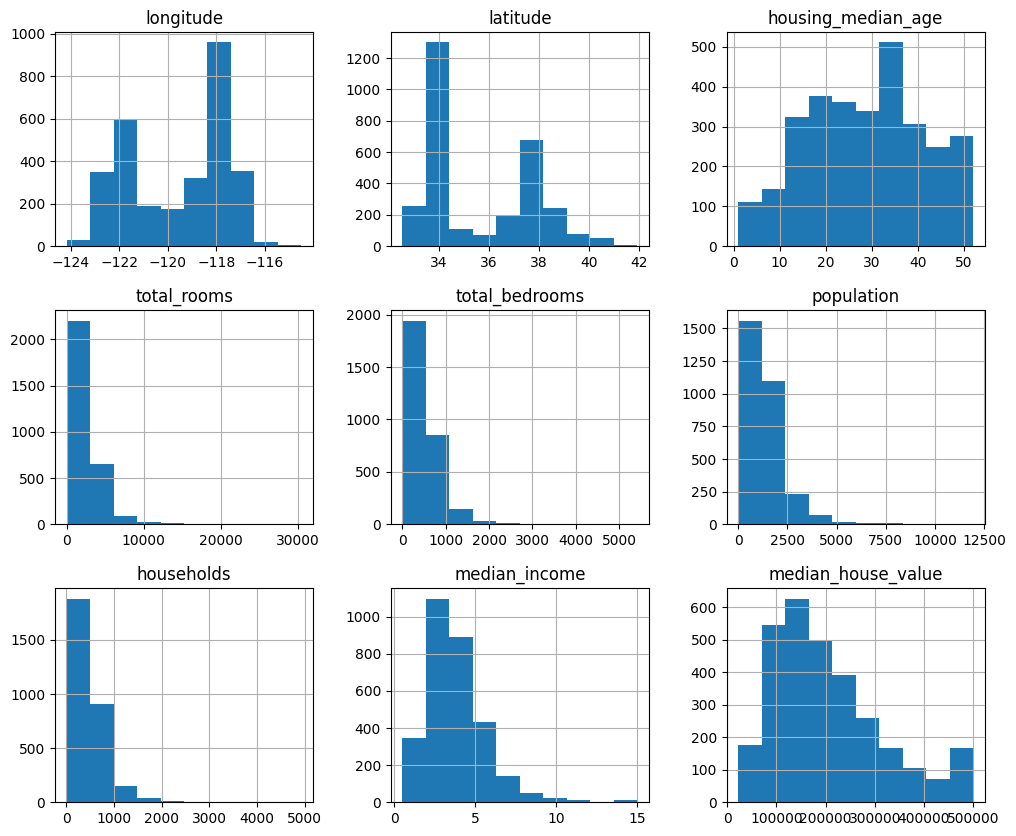

In [9]:
df.hist(figsize=(12,10))
plt.show()

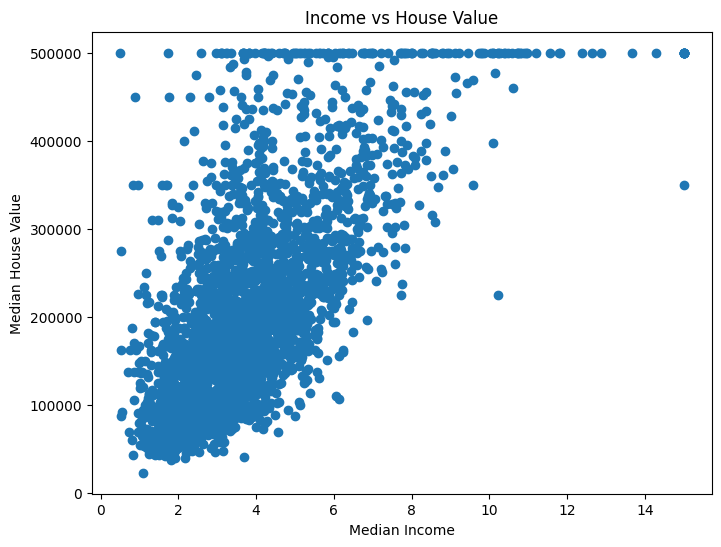

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(df["median_income"],
            df["median_house_value"])

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Income vs House Value")

plt.show()

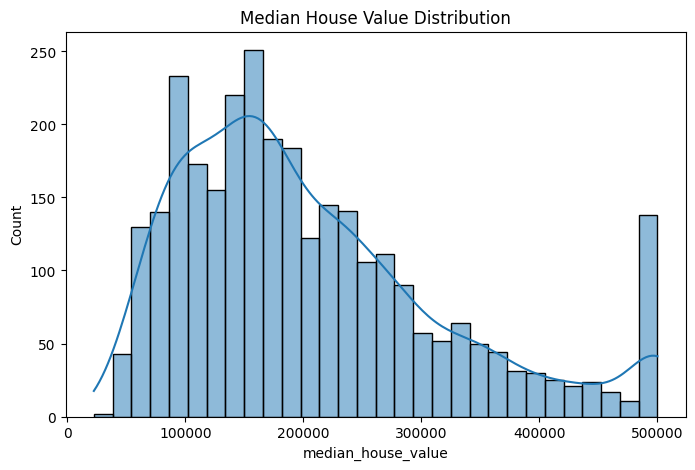

In [11]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['median_house_value'], bins=30, kde=True)
plt.title("Median House Value Distribution")
plt.show()

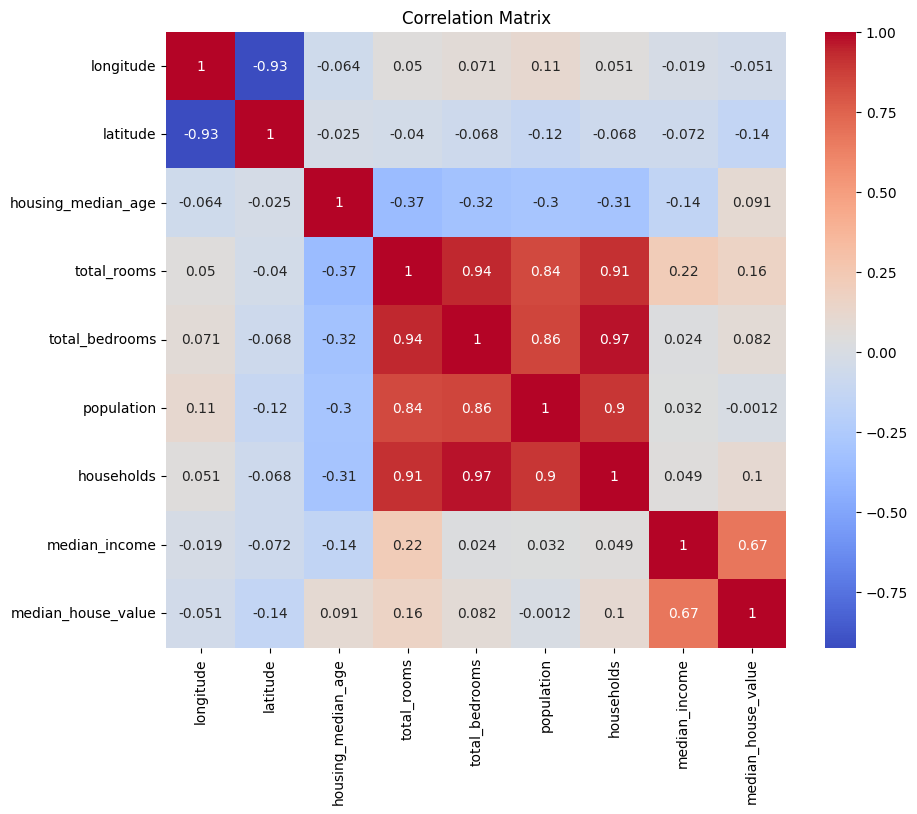

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [13]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [16]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
y_pred = model.predict(X_test)

In [18]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 39345.21026666667
Mean Squared Error : 3315046418.020424
Root Mean Squared Error : 57576.439782435526
R2 Score : 0.7367657879959226


In [19]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
7       median_income    0.514774
1            latitude    0.129944
0           longitude    0.127984
2  housing_median_age    0.083619
5          population    0.049008
4      total_bedrooms    0.039660
3         total_rooms    0.028787
6          households    0.026225


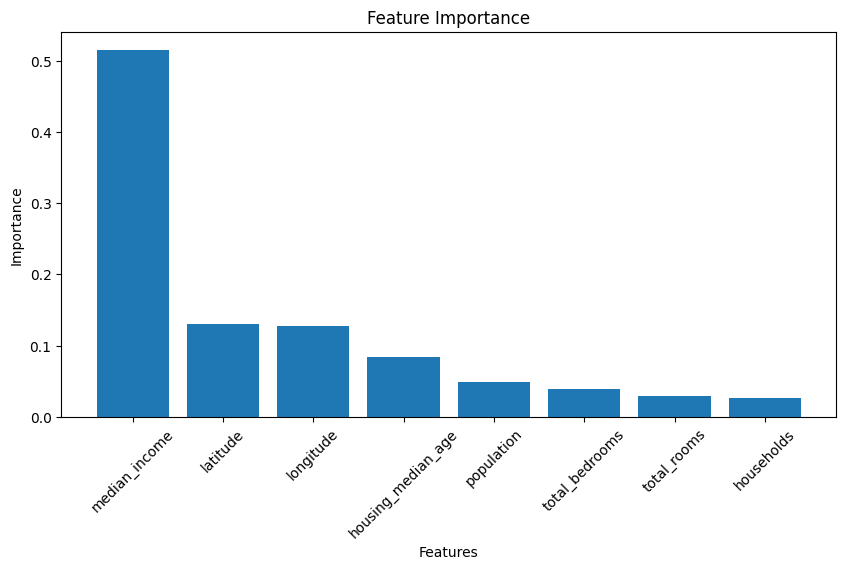

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

In [21]:
new_house = [[
    -122.05,   # longitude
    37.37,     # latitude
    27,        # housing_median_age
    3885,      # total_rooms
    661,       # total_bedrooms
    1537,      # population
    606,       # households
    6.60       # median_income
]]

prediction = model.predict(new_house)

print("Predicted Median House Value: $", prediction[0])

Predicted Median House Value: $ 399463.25


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Perform processing and feature preparation

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [23]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

First 5 Rows
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  

Dataset Shape:
(3000, 9)


In [24]:
print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
None

Summary Statistics
         longitude    latitude  housing_median_age   total_rooms  \
count  3000.000000  3000.00000         3000.000000   3000.000000   
mean   -119.589200    35.63539           28.845333   2599.578667   
std       1.994936     2.12967           12.555396   2155.59333

In [25]:
print("\nMissing Values")
print(df.isnull().sum())

# If any missing values exist, fill them with column mean
df = df.fillna(df.mean(numeric_only=True))



Missing Values
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [26]:
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()


Duplicate Rows: 0


In [27]:
# Target Variable
y = df['median_house_value']

# Features
X = df.drop('median_house_value', axis=1)

print("\nFeatures")
print(X.columns)


Features
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')


In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Features Shape:")
print(X_scaled.shape)


Scaled Features Shape:
(3000, 8)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Set Shape")
print(X_train.shape)

print("Testing Set Shape")
print(X_test.shape)


Training Set Shape
(2400, 8)
Testing Set Shape
(600, 8)


In [30]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

print("\nProcessed Training Data")
print(X_train.head())


Processed Training Data
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   0.636317 -0.725769           -0.067340    -0.197927        0.695524   
1   0.566127 -0.688198           -0.385981     0.099489        0.349024   
2   0.866939 -0.899534            0.171641    -0.652170       -0.560537   
3   0.726560 -0.753947            0.729264    -0.534781       -0.570162   
4  -1.414216  0.927345            1.366546     0.174191        0.272025   

   population  households  median_income  
0    1.111445    0.747445      -1.039947  
1    0.058427    0.356053       0.205063  
2    0.193330   -0.503370      -0.794936  
3   -0.350164   -0.563584       0.178097  
4    0.073955    0.238361       0.007620  


Train regression and classification models

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

In [33]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  
(3000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  -

In [34]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [35]:
df = df.fillna(df.mean(numeric_only=True))

In [36]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [39]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)

In [41]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 49554.276208268304
MSE : 4586505886.68125
RMSE : 67723.74684467222
R2 Score : 0.6358044169850408


In [42]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

     Actual      Predicted
0  119400.0  126565.069443
1  133600.0  145859.800832
2  173600.0  247176.001173
3  218600.0  207110.679931
4  276700.0  194794.790395
5  146800.0  175428.699974
6  166300.0  229747.207280
7  197200.0  163606.508357
8  162500.0   69564.074478
9  287800.0  197037.575346


In [43]:
median = df['median_house_value'].median()

df['Price_Class'] = np.where(
    df['median_house_value'] >= median,
    1,
    0
)

In [44]:
X = df.drop(['median_house_value', 'Price_Class'], axis=1)

y = df['Price_Class']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [47]:
classifier = LogisticRegression()

classifier.fit(X_train, y_train)

LogisticRegression()

In [48]:
y_pred = classifier.predict(X_test)

In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")

print(classification_report(y_test, y_pred))

Accuracy: 0.8283333333333334

Confusion Matrix
[[259  51]
 [ 52 238]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       310
           1       0.82      0.82      0.82       290

    accuracy                           0.83       600
   macro avg       0.83      0.83      0.83       600
weighted avg       0.83      0.83      0.83       600



In [50]:
sample = X.iloc[[0]]

sample = scaler.transform(sample)

prediction = classifier.predict(sample)

print("Predicted Class:", prediction[0])

Predicted Class: 1


Predective output and performance

In [51]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [52]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [53]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [56]:
y_pred = model.predict(X_test)

In [57]:
prediction = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

prediction.head(10)

,Actual Price,Predicted Price
1801,119400.0,126565.069443
1190,133600.0,145859.800832
1817,173600.0,247176.001173
251,218600.0,207110.679931
2505,276700.0,194794.790395
1117,146800.0,175428.699974
1411,166300.0,229747.207280
2113,197200.0,163606.508357
408,162500.0,69564.074478
2579,287800.0,197037.575346


In [58]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 49554.27620826821


In [59]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 4586505886.68125


In [60]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 67723.74684467222


In [61]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6358044169850408


In [62]:
print("========== Model Performance ==========")

print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

========== Model Performance ==========
MAE : 49554.27620826821
MSE : 4586505886.68125
RMSE : 67723.74684467222
R2 Score : 0.6358044169850408


In [63]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(20)

,Actual,Predicted
0,119400.0,126565.069443
1,133600.0,145859.800832
2,173600.0,247176.001173
3,218600.0,207110.679931
4,276700.0,194794.790395
5,146800.0,175428.699974
6,166300.0,229747.207280
7,197200.0,163606.508357
8,162500.0,69564.074478
9,287800.0,197037.575346


In [64]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted House Value:", prediction[0])

Predicted House Value: 352698.2361933137


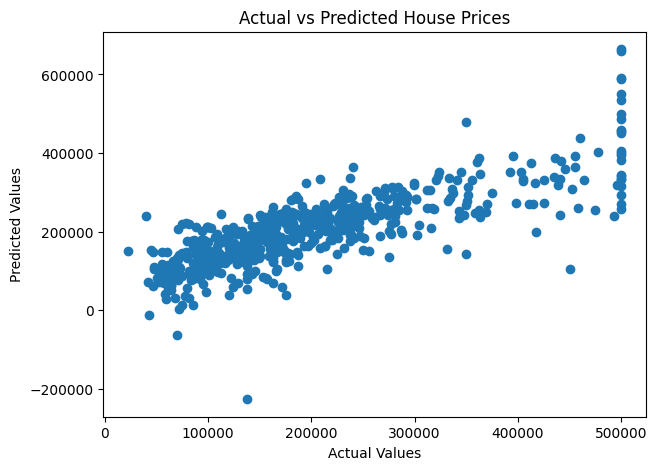

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.show()

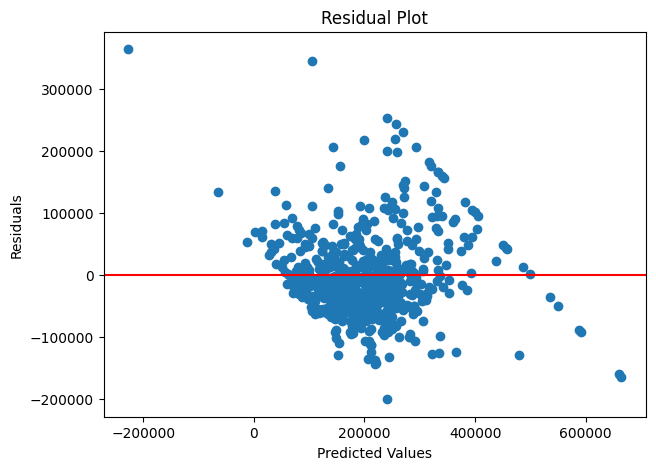

In [66]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()